**Predicting Loan Approval Decisions Using Machine Learning Classification Models**

- Overview

This project focuses on predicting loan approval status using machine learning techniques. The dataset contains applicant demographic, financial, employment, and credit-related information that can help determine whether a loan application is likely to be approved.

The objective is to build an intelligent classification model capable of assisting financial institutions in making faster, more consistent, and data-driven lending decisions.

In [105]:
# %pip install -q -U kagglehub

#### **Requirement Gathering, Data Source**

In [106]:
import os
import kagglehub
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings


warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")

%matplotlib inline

def show_layout():
    plt.figure(figsize=(9, 4))
    plt.tight_layout()
    plt.show()

In [107]:
# Download latest version
path = kagglehub.dataset_download("muhammadmusharraf444/loan-approval-dataset")
source_path = path
destination_path = os.getcwd()

# Copy dataset from source directory to destination directory
source_path = path
destination_path = os.getcwd()

shutil.copytree(source_path, destination_path, dirs_exist_ok = True)

'c:\\Users\\AYO_AYO\\Desktop\\Machine-Learning-Bootcamp'

In [108]:
source_path

'C:\\Users\\AYO_AYO\\.cache\\kagglehub\\datasets\\muhammadmusharraf444\\loan-approval-dataset\\versions\\1'

In [109]:
loan_df = pd.read_csv("./loan_data_new.csv")
loan_df.head()

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


#### **Dataset Overview**

In [140]:
20 / 7460 * 100

0.2680965147453083

In [110]:
print(f"Rows: {loan_df.shape[0]}, Columns: {loan_df.shape[1]}")
print(loan_df.columns.to_list())
print(loan_df.isna().sum())
print(loan_df.info())

Rows: 45000, Columns: 14
['Age', 'Gender', 'Education', 'Person Income', 'Employee Experience', 'Home Onwership', 'Loan Amount', 'Loan Intent', 'Loan interest Rate', 'Loan percentage', 'Credit History', 'Credit Score', 'Previous Loan', 'Loan Status']
Age                    0
Gender                 0
Education              0
Person Income          0
Employee Experience    0
Home Onwership         0
Loan Amount            0
Loan Intent            0
Loan interest Rate     0
Loan percentage        0
Credit History         0
Credit Score           0
Previous Loan          0
Loan Status            0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  45000 non-null  int64  
 1   Gender               45000 non-null  object 
 2   Education            45000 non-null  object 
 3   Person Income        4

In [111]:
print(f"{loan_df.duplicated().sum()} duplicate/s was found in this dataset")

0 duplicate/s was found in this dataset


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

education_encoder = OrdinalEncoder(
    categories=[education_order],          # the order list from Step 1
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

education_encoder.fit(X_train[["education"]])

X_train["education"] = education_encoder.transform(X_train[["education"]])
X_test["education"] = education_encoder.transform(X_test[["education"]])

#### **Cleaning and Standardization**

In [112]:
loan_df.columns = (loan_df.columns.str.strip().str.replace(" ", "_").str.lower())

loan_df = loan_df.rename(columns={"home_onwership": "home_ownership"})

columns_to_lower = ["loan_intent", "home_ownership"]
loan_df[columns_to_lower] = loan_df[columns_to_lower].apply(lambda x: x.str.lower())

In [113]:
# Assuming your target column name is 'loan_status'
# loan_df['loan_status'] = loan_df['loan_status'].map({"Yes": 1, "No": 0})

numerical_cols = loan_df.select_dtypes([np.number]).columns.to_list()
categorical_cols = [col for col in loan_df.columns if col not in numerical_cols]

print(numerical_cols)
print(categorical_cols)

['age', 'person_income', 'employee_experience', 'loan_amount', 'loan_interest_rate', 'loan_percentage', 'credit_history', 'credit_score', 'loan_status']
['gender', 'education', 'home_ownership', 'loan_intent', 'previous_loan']


### **Univariate Analysis**

In [114]:
print("Summary statistics for numerical columns:")
print(loan_df[numerical_cols].describe())
print(loan_df[numerical_cols].isna().sum())

Summary statistics for numerical columns:
                age  person_income  employee_experience   loan_amount  \
count  45000.000000   4.500000e+04         45000.000000  45000.000000   
mean      27.764178   8.031905e+04             5.410333   9583.157556   
std        6.045108   8.042250e+04             6.063532   6314.886691   
min       20.000000   8.000000e+03             0.000000    500.000000   
25%       24.000000   4.720400e+04             1.000000   5000.000000   
50%       26.000000   6.704800e+04             4.000000   8000.000000   
75%       30.000000   9.578925e+04             8.000000  12237.250000   
max      144.000000   7.200766e+06           125.000000  35000.000000   

       loan_interest_rate  loan_percentage  credit_history  credit_score  \
count        45000.000000     45000.000000    45000.000000  45000.000000   
mean            11.006606         0.139725        5.867489    632.608756   
std              2.978808         0.087212        3.879702     50.435865

In [115]:
numerical_summary = loan_df[numerical_cols].agg(["mean", "var", "std"])
numerical_summary

,age,person_income,employee_experience,loan_amount,loan_interest_rate,loan_percentage,credit_history,credit_score,loan_status
mean,27.764178,8.031905e+04,5.410333,9.583158e+03,11.006606,0.139725,5.867489,632.608756,0.222222
var,36.543333,6.467778e+09,36.766421,3.987779e+07,8.873299,0.007606,15.052086,2543.776478,0.172843
std,6.045108,8.042250e+04,6.063532,6.314887e+03,2.978808,0.087212,3.879702,50.435865,0.415744


In [116]:
print(loan_df[numerical_cols].skew()) # type: ignoreow
print(loan_df[numerical_cols].kurtosis()) # type: ignore

age                     2.548154
person_income          34.137583
employee_experience     2.594917
loan_amount             1.179731
loan_interest_rate      0.213784
loan_percentage         1.034512
credit_history          1.631720
credit_score           -0.610261
loan_status             1.336351
dtype: float64
age                      18.649449
person_income          2398.684769
employee_experience      19.168324
loan_amount               1.351215
loan_interest_rate       -0.420335
loan_percentage           1.082416
credit_history            3.725945
credit_score              0.203022
loan_status              -0.214176
dtype: float64


In [117]:
age_counts = loan_df["age"].value_counts().sort_index()
print(age_counts.head())

age
20      17
21    1289
22    4236
23    5254
24    5138
Name: count, dtype: int64


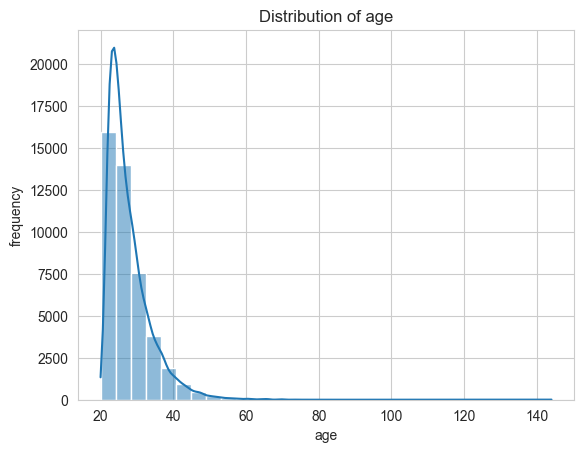

<Figure size 900x400 with 0 Axes>

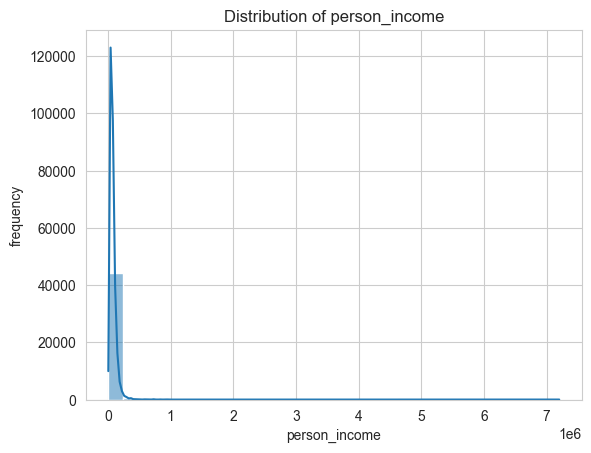

<Figure size 900x400 with 0 Axes>

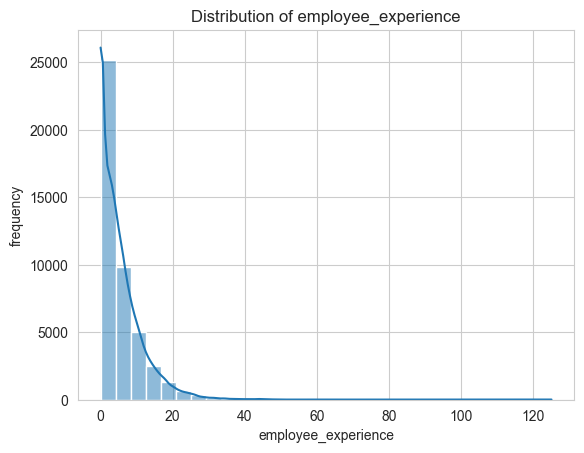

<Figure size 900x400 with 0 Axes>

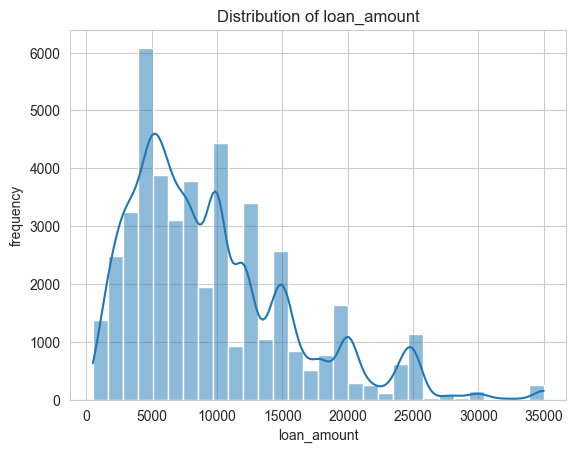

<Figure size 900x400 with 0 Axes>

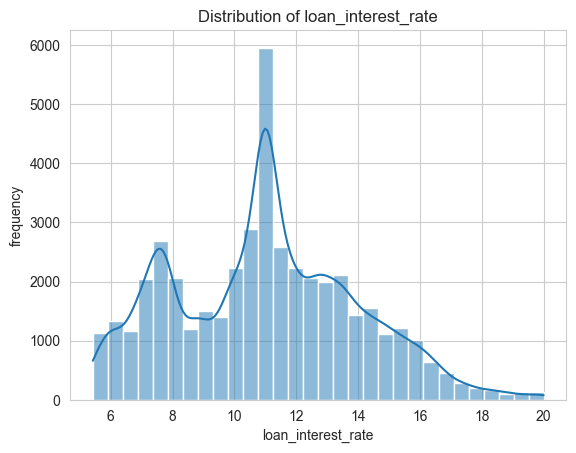

<Figure size 900x400 with 0 Axes>

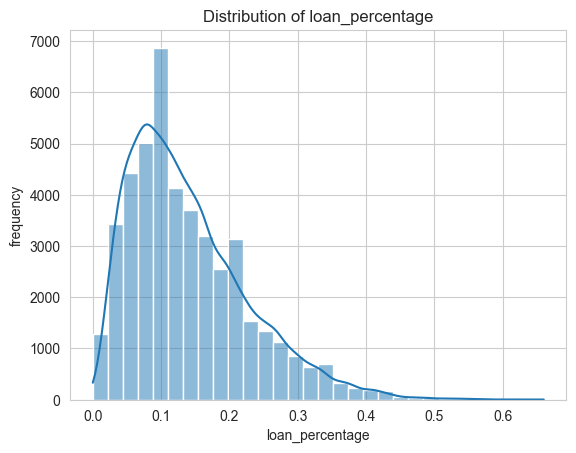

<Figure size 900x400 with 0 Axes>

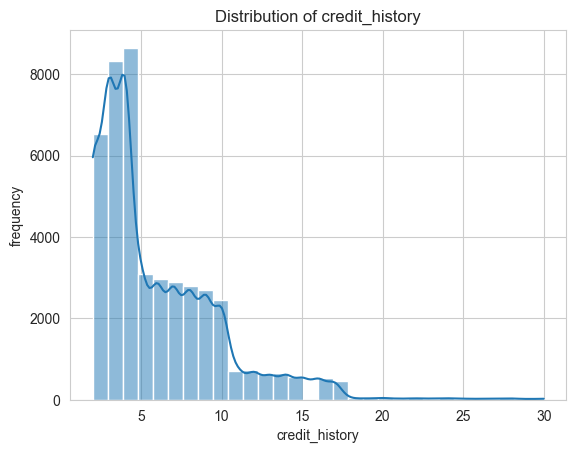

<Figure size 900x400 with 0 Axes>

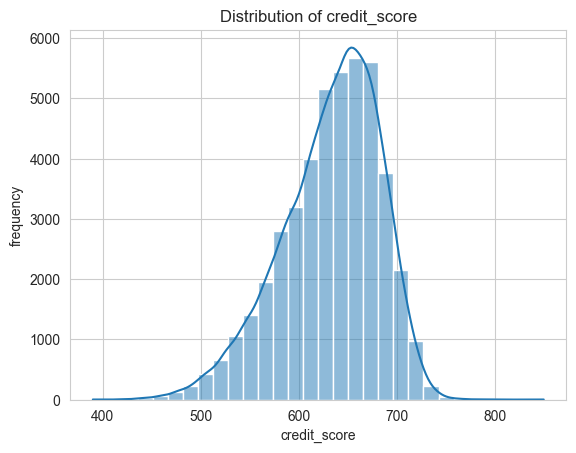

<Figure size 900x400 with 0 Axes>

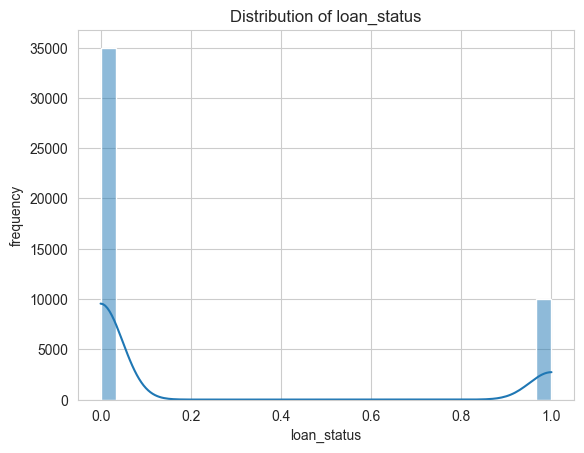

<Figure size 900x400 with 0 Axes>

In [118]:
for cols in numerical_cols:
    sns.histplot(x = loan_df[cols], kde = True, bins = 30)
    plt.title(f"Distribution of {cols}")
    plt.xlabel(cols)
    plt.ylabel("frequency")
    show_layout()

#### **Exploratory Data Analysis**

In [119]:
loan_approved_percentage = loan_df['loan_status'].value_counts(normalize=True).round(3).mul(100)
# Highly imbalanced dataset, 78% of loan request were rejected whilst only 22% were accepted, since the model is right 78% of the time, it'll treat others as same (reject)

In [120]:
salary_threshold = loan_df["person_income"].mean()
print(f"Salary threshold: {round((salary_threshold),2)}")

Salary threshold: 80319.05


In [121]:
# Do applicants with higher incomes get approved more often?

higher_income_group = loan_df[loan_df.loc[:, "person_income"] >= salary_threshold]
lower_income_group = loan_df[loan_df.loc[:, "person_income"] < salary_threshold]

# 2. Extract the exact approval rates
high_income_approval = (higher_income_group["loan_status"] == 1).mean() * 100
low_income_approval = (lower_income_group["loan_status"] == 1).mean() * 100
 
# Loan approval differences
print(f"High income loan approval rate: {high_income_approval:.2f}%")
print(f"Low income loan approval rate: {low_income_approval:.2f}%")
print(f"Difference in approval rates: {high_income_approval - low_income_approval:.2f}%")

High income loan approval rate: 11.56%
Low income loan approval rate: 28.27%
Difference in approval rates: -16.71%


In [122]:
# Does education level affect approval rates?

education_approval_rate = loan_df.groupby(loan_df["education"])["loan_status"].mean().mul(100).sort_values(ascending=False)
print(education_approval_rate.round(2))

education
Doctorate      22.87
Bachelor       22.52
High School    22.31
Associate      22.03
Master         21.76
Name: loan_status, dtype: float64


In [123]:
target_column = "loan_status"

In [124]:
print(f"Rows before dropping missing target values: {loan_df.shape[0]}")

missing_target_count = loan_df[target_column].isna().sum()
print(f"Missing values in target column '{target_column}': {missing_target_count}")

# Dropping rows with missing target values
loan_df.dropna(subset=[target_column], inplace=True)
print(f"Rows after dropping missing target values: {loan_df.shape[0]}")

Rows before dropping missing target values: 45000
Missing values in target column 'loan_status': 0
Rows after dropping missing target values: 45000


**Feature & Target Separation**

In [125]:
X = loan_df.drop(columns=[target_column], axis=1)
y = loan_df[target_column]


print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (45000, 13)
Target Shape: (45000,)


In [126]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=.2,
    random_state=42,
    stratify= y
) 

In [127]:
print("Target Distribution Full dataset")
print(y.value_counts(normalize=True).round(3))

print("-"*20)
print("Target Distribution Train set")
print(y_train.value_counts(normalize=True).round(3))

print("-"*20)
print("Target Distribution Test set")
print(y_test.value_counts(normalize=True).round(3))

Target Distribution Full dataset
loan_status
0    0.778
1    0.222
Name: proportion, dtype: float64
--------------------
Target Distribution Train set
loan_status
0    0.778
1    0.222
Name: proportion, dtype: float64
--------------------
Target Distribution Test set
loan_status
0    0.778
1    0.222
Name: proportion, dtype: float64


In [128]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(36000, 13)
(36000,)
(9000, 13)
(9000,)


In [129]:
Loan_Train_df = X_train.copy()
Loan_Train_df[target_column] = y_train.values

Loan_Test_df = X_test.copy()
Loan_Test_df[target_column] = y_test.values

In [130]:
Loan_train_encoder = Loan_Train_df.copy()
Loan_test_encoder = Loan_Test_df.copy()

In [ ]:
def multi_line_space():
    print()
    
print("X_Train Columns:", Loan_train_encoder.columns)
multi_line_space()
print("X_Test Columns:", Loan_test_encoder.columns)

X_Train Columns: Index(['age', 'gender', 'education', 'person_income', 'employee_experience',
       'home_ownership', 'loan_amount', 'loan_intent', 'loan_interest_rate',
       'loan_percentage', 'credit_history', 'credit_score', 'previous_loan',
       'loan_status'],
      dtype='object')

X_Test Columns: Index(['age', 'gender', 'education', 'person_income', 'employee_experience',
       'home_ownership', 'loan_amount', 'loan_intent', 'loan_interest_rate',
       'loan_percentage', 'credit_history', 'credit_score', 'previous_loan',
       'loan_status'],
      dtype='object')


**Encode Ordinal Features**

In [132]:
# Hardcoded feature extraction

ordinal_cols = ["gender", "education", "previous_loan"]
norminal_cols = ["loan_intent", "home_ownership"]s

SyntaxError: invalid syntax (3672185990.py, line 4)

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoded_cols = {}

for cols in ordinal_cols:
    l_encoder = LabelEncoder()
    l_encoded = l_encoder.fit(Loan_train_encoder[cols])
    encoded_cols[cols] = l_encoded
    
    Loan_train_encoder[cols] = l_encoder.transform(Loan_train_encoder[cols])
    Loan_test_encoder[cols] = l_encoder.transform(Loan_test_encoder[cols])

In [ ]:
for i, v in encoded_cols.items():
    print(i, ":", v)

gender : LabelEncoder()
education : LabelEncoder()
previous_loan : LabelEncoder()


In [ ]:
Loan_train_encoder.head()

,age,gender,education,person_income,employee_experience,home_ownership,loan_amount,loan_intent,loan_interest_rate,loan_percentage,credit_history,credit_score,previous_loan,loan_status
6048,24,1,4,58914,2,own,4400,venture,5.99,0.07,4,656,1,0
3346,23,0,3,45873,2,rent,11000,venture,11.01,0.24,2,634,1,0
17998,29,0,4,240947,7,mortgage,10000,venture,12.69,0.04,9,638,1,0
24988,30,0,1,96316,10,mortgage,6000,medical,13.49,0.06,8,682,0,0
23231,29,1,1,73033,7,mortgage,8000,personal,10.51,0.11,8,644,1,0


**Encode Norminal Features**

In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe_encoder = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

# Fit/Train 
Loan_train_ohe_encoder = ohe_encoder.fit(Loan_train_encoder[norminal_cols])
Loan_test_ohe_encoder = ohe_encoder.fit(Loan_test_encoder[norminal_cols])

# Transform/Learn
Loan_train_ohe_encoder = ohe_encoder.transform(Loan_train_encoder[norminal_cols])
Loan_test_ohe_encoder = ohe_encoder.transform(Loan_test_encoder[norminal_cols])

In [ ]:
# get_feature_names_out() takes the input feature names that were used to fit the encoder. In most cases, that's simply the list of categorical column names

ohe_cols = ohe_encoder.get_feature_names_out()
print("Original Dataframe Columns:", ohe_cols)

Original Dataframe Columns: ['loan_intent_education' 'loan_intent_homeimprovement'
 'loan_intent_medical' 'loan_intent_personal' 'loan_intent_venture'
 'home_ownership_other' 'home_ownership_own' 'home_ownership_rent']


In [ ]:
Loan_train_ohe_encoder

array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 0., 1.]], shape=(36000, 8))

**Using Column Transformer**

In [ ]:
# from sklearn.compose import ColumnTransformer
# from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# preprocessor = ColumnTransformer(
#     transformers=[
#         ("one_hot_encoder", OneHotEncoder(
#             drop="first",
#             sparse_output=False,
#             handle_unknown="ignore"
#         ), norminal_cols),
#         ("ordinal_cols", OrdinalEncoder(), ordinal_cols)
#     ],
#     remainder="passthrough"
# )

# preprocessor.fit(X_train_encoder)

**To make it easier to work with, convert it back to a DataFrame:**

In [ ]:
Loan_train_encoder = pd.DataFrame(
    Loan_train_ohe_encoder,
    columns=ohe_cols,
    index=Loan_train_encoder.index
)

Loan_test_encoder = pd.DataFrame(
    Loan_test_ohe_encoder,
    columns=ohe_cols,
    index=Loan_test_encoder.index
)

**Now remove the original nominal columns:**

In [ ]:
Loan_train_encoder

,loan_intent_education,loan_intent_homeimprovement,loan_intent_medical,loan_intent_personal,loan_intent_venture,home_ownership_other,home_ownership_own,home_ownership_rent
6048,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3346,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
17998,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
24988,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
23231,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
3245,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
17803,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
28842,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
21553,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
print(Loan_train_encoder.columns.tolist())
print(norminal_cols)

['loan_intent_education', 'loan_intent_homeimprovement', 'loan_intent_medical', 'loan_intent_personal', 'loan_intent_venture', 'home_ownership_other', 'home_ownership_own', 'home_ownership_rent']
['loan_intent', 'home_ownership']


In [ ]:
# Loan_train_encoder = Loan_train_encoder.drop(columns=norminal_cols)
# # Loan_test_encoder = Loan_test_encoder.drop(columns=norminal_cols)

# print("Loan Training")
# print(Loan_train_encoder.shape)
# print(Loan_test_encoder.columns)
# multi_line_space()
# print("Loan Testing")
# print(Loan_train_encoder.shape)
# print(Loan_test_encoder.columns)

**Then concatenate the encoded columns:**

In [ ]:
X_train_encoder = pd.concat(
    [X_train_encoder, X_test_encoder],
    axis=1
)
print(X_train_encoder.shape)
print(X_train_encoder.columns)

(45000, 26)
Index(['age', 'gender', 'education', 'person_income', 'employee_experience',
       'loan_amount', 'loan_interest_rate', 'loan_percentage',
       'credit_history', 'credit_score', 'previous_loan', 'loan_status', 'age',
       'gender', 'education', 'person_income', 'employee_experience',
       'home_ownership', 'loan_amount', 'loan_intent', 'loan_interest_rate',
       'loan_percentage', 'credit_history', 'credit_score', 'previous_loan',
       'loan_status'],
      dtype='object')


In [ ]:
Loan_train_encoder = Loan_Train_df.copy()

# One-hot encode
encoded = ohe_encoder.fit_transform(Loan_train_encoder[norminal_cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe_encoder.get_feature_names_out(norminal_cols),
    index=Loan_train_encoder.index
)
print("Before drop:")
print(Loan_train_encoder.columns)
print("Columns to drop:", norminal_cols)

# Remove original categorical columns
Loan_train_encoder = Loan_train_encoder.drop(columns=norminal_cols)

print("After drop", Loan_train_encoder.columns)

# # Add encoded columns
# Loan_train_encoder = pd.concat([Loan_train_encoder, encoded_df], axis=1)

Before drop:
Index(['age', 'gender', 'education', 'person_income', 'employee_experience',
       'home_ownership', 'loan_amount', 'loan_intent', 'loan_interest_rate',
       'loan_percentage', 'credit_history', 'credit_score', 'previous_loan',
       'loan_status'],
      dtype='object')
Columns to drop: ['loan_intent', 'home_ownership']
After drop Index(['age', 'gender', 'education', 'person_income', 'employee_experience',
       'loan_amount', 'loan_interest_rate', 'loan_percentage',
       'credit_history', 'credit_score', 'previous_loan', 'loan_status'],
      dtype='object')
